In [1]:
import pandas as pd
import numpy as np
import h3
from shapely.geometry import Polygon
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import json
import plotly.express as px

In [3]:
df_crime_boston = pd.read_parquet('RawDataset/BostonCrime.parquet', engine='fastparquet')
df_crime_boston = df_crime_boston[['INCIDENT_NUMBER','OFFENSE_DESCRIPTION','DAY_OF_WEEK','DISTRICT',
                                   'OCCURRED_ON_DATE','HOUR','YEAR','Lat','Long']]
df_crime_boston = df_crime_boston.loc[
    (~df_crime_boston["DISTRICT"].isin(["External", "None", "Outside of"])) 
    & df_crime_boston["DISTRICT"].notna()
]

df_crime_la = pd.read_parquet('RawDataset/LACrime.parquet', engine='fastparquet')
df_crime_la = df_crime_la[['DR_NO','AREA','DATE OCC','TIME OCC','Crm Cd Desc','LAT','LON']]

In [4]:
def classify_crime_boston(desc):
    desc = str(desc).upper()

    # --- ASSAULT / BATTERY (Violent crimes) ---
    if any(keyword in desc for keyword in [
        'ASSAULT',
        'BATTERY',
        'THREATS',
        'ROBBERY',
        'INTIMIDATING WITNESS',
        'KIDNAPPING',
        'AFFRAY'
    ]):
        return 'ASSAULT/BATTERY'

    # --- THEFT (Property crimes) ---
    elif any(keyword in desc for keyword in [
        'LARCENY',
        'THEFT',
        'BURGLARY',
        'B&E',
        'AUTO THEFT',
        'SHOPLIFTING',
        'PICK-POCKET',
        'PURSE SNATCH',
        'FRAUD',
        'EMBEZZLEMENT',
        'FORGERY',
        'STOLEN PROPERTY'
    ]):
        return 'THEFT'

    # --- OTHERS ---
    else:
        return 'OTHERS'


# Apply to dataframe
df_crime_boston['CRIME_CATEGORY'] = df_crime_boston['OFFENSE_DESCRIPTION'].apply(classify_crime_boston)

In [5]:
def classify_crime_la(desc):
    desc = str(desc).upper()

    # --- BATTERY (physical contact crimes explicitly labeled) ---
    if any(keyword in desc for keyword in [
        'BATTERY'
    ]):
        return 'BATTERY'

    # --- ASSAULT (threat or attempt, no explicit battery label) ---
    elif any(keyword in desc for keyword in [
        'ASSAULT',
        'CRIMINAL THREATS',
        'THREATENING',
        'BRANDISH WEAPON',
        'STALKING',
        'KIDNAPPING',
        'FALSE IMPRISONMENT',
        'LYNCHING'
    ]):
        return 'ASSAULT'

    # --- THEFT (property-related crimes) ---
    elif any(keyword in desc for keyword in [
        'THEFT',
        'STOLEN',
        'BURGLARY',
        'ROBBERY',
        'SHOPLIFTING',
        'PICKPOCKET',
        'PURSE SNATCHING',
        'EMBEZZLEMENT',
        'FRAUD',
        'BUNCO',
        'COUNTERFEIT',
        'DEFRAUDING',
        'AUTO REPAIR',
        'TILL TAP',
        'COIN MACHINE'
    ]):
        return 'THEFT'

    # --- OTHERS ---
    else:
        return 'OTHERS'


# Apply to LA dataframe
df_crime_la['CRIME_CATEGORY'] = df_crime_la['Crm Cd Desc'].apply(classify_crime_la)

In [6]:
# --- Boston ---
before_boston = len(df_crime_boston)
df_crime_boston = df_crime_boston.drop_duplicates()
after_boston = len(df_crime_boston)

print(f"Boston - Before: {before_boston}, After: {after_boston}, Dropped: {before_boston - after_boston}")


# --- LA ---
before_la = len(df_crime_la)
df_crime_la = df_crime_la.drop_duplicates()
after_la = len(df_crime_la)

print(f"LA - Before: {before_la}, After: {after_la}, Dropped: {before_la - after_la}")

Boston - Before: 252846, After: 252846, Dropped: 0
LA - Before: 1004894, After: 1004894, Dropped: 0


# Boston Crime Data Preprocessing

In [7]:
df_crime_boston.head(5)

,INCIDENT_NUMBER,OFFENSE_DESCRIPTION,DAY_OF_WEEK,DISTRICT,OCCURRED_ON_DATE,HOUR,YEAR,Lat,Long,CRIME_CATEGORY
0,232007173,INVESTIGATE PERSON,Friday,B3,2023-01-27 22:44:00+00,22,2023,42.271661,-71.099534,OTHERS
1,232004454,VERBAL DISPUTE,Tuesday,B2,2023-01-17 20:21:00+00,20,2023,42.312597,-71.092875,OTHERS
2,232006290,INVESTIGATE PERSON,Tuesday,A1,2023-01-24 00:00:00+00,0,2023,42.365700,-71.052892,OTHERS
3,232024939,INVESTIGATE PROPERTY,Friday,B3,2023-03-31 17:14:00+00,17,2023,42.292788,-71.088519,OTHERS
4,232006708,ASSAULT - AGGRAVATED,Thursday,B2,2023-01-26 09:00:00+00,9,2023,42.310269,-71.089310,ASSAULT/BATTERY


In [8]:
df_crime_boston['OCCURRED_ON_DATE'] = pd.to_datetime(df_crime_boston['OCCURRED_ON_DATE'])

In [9]:
df_crime_boston = df_crime_boston.loc[df_crime_boston.CRIME_CATEGORY != 'OTHERS'].reset_index(drop=True)
df_crime_boston = df_crime_boston.dropna()
df_crime_boston.columns = ['incident_number','offense_description','day_of_week','district','Date','hour','year','Latitude','Longitude','crime_category']
df_crime_boston = df_crime_boston.loc[(df_crime_boston.year >= 2022) & (df_crime_boston.year <= 2025)]

In [10]:
# Build H3 spatial grid and create shift-level target variable
# Shift bins: morning/noon (06:00-13:59), afternoon/night (14:00-21:59), overnight (22:00-05:59)

RESOLUTION = 8  # Higher number = smaller hexagons e.g. 8 is ~0.7km^2 area

# 1) Assign H3 cell id to each record
df_crime_boston["h3_address"] = df_crime_boston.apply(
    lambda row: h3.latlng_to_cell(row["Latitude"], row["Longitude"], RESOLUTION),
    axis=1
)

# 2) Clean copy: ensure datetime, drop missing coordinates/dates
df_shift = df_crime_boston.copy()
df_shift["Date"] = pd.to_datetime(df_shift["Date"], errors="coerce")
df_shift = df_shift.dropna(subset=["Date", "h3_address"]).copy()

# 3) Assign each record to a shift and shift_date (anchored to shift start date)
hour = df_shift["Date"].dt.hour
df_shift["shift"] = np.select(
    [hour.between(6, 13), hour.between(14, 21)],
    ["morning_noon", "afternoon_night"],
    default="overnight"
)
df_shift["shift_date"] = df_shift["Date"].dt.floor("D")
df_shift.loc[hour < 6, "shift_date"] -= pd.Timedelta(days=1)

# 4) Build gdf_tiles for mapping (daily crime counts per tile)
def h3_to_polygon(hex_id):
    boundary = h3.cell_to_boundary(hex_id)  # (lat, lng)
    return Polygon([(lng, lat) for lat, lng in boundary])

tile_counts = (
    df_shift.groupby(["h3_address", df_shift["Date"].dt.date])
    .size().reset_index(name="crime_count")
)
tile_counts.columns = ["h3_address", "Date", "crime_count"]
gdf_tiles = gpd.GeoDataFrame(
    tile_counts,
    geometry=tile_counts["h3_address"].apply(h3_to_polygon),
    crs="EPSG:4326"
)

# 5) Aggregate crimes per tile per shift, then build master grid (every tile × date × shift)
tile_shift_counts = (
    df_shift.groupby(["h3_address", "shift_date", "shift"]).size().reset_index(name="crime_count")
)
shift_order = ["morning_noon", "afternoon_night", "overnight"]
index = pd.MultiIndex.from_product(
    [df_shift["h3_address"].unique(),
     pd.date_range(df_shift["shift_date"].min(), df_shift["shift_date"].max(), freq="D"),
     shift_order],
    names=["h3_address", "shift_date", "shift"]
)
master_grid = pd.DataFrame(index=index).reset_index()

# 6) Merge actual counts, fill zeros, create binary target
final_df = pd.merge(master_grid, tile_shift_counts, on=["h3_address", "shift_date", "shift"], how="left")
final_df["crime_count"] = final_df["crime_count"].fillna(0)
final_df["target"] = (final_df["crime_count"] > 0).astype(int)

# 7) Add Date and hour columns
# hour reflects the first (earliest) crime in that specific tile and shift;
# falls back to shift start hour for zero-crime rows
shift_start_hour = {"morning_noon": 6, "afternoon_night": 14, "overnight": 22}
final_df["Date"] = final_df["shift_date"] + pd.to_timedelta(final_df["shift"].map(shift_start_hour), unit="h")
hour_map = df_shift.groupby(["h3_address", "shift_date", "shift"])["Date"].apply(lambda x: int(x.min().hour)).to_dict()
final_df["hour"] = final_df.apply(
    lambda row: hour_map.get((row["h3_address"], row["shift_date"], row["shift"]), shift_start_hour[row["shift"]]),
    axis=1
)

print(f"H3 feature table created at resolution {RESOLUTION}")
print(f"Crime records used: {len(df_shift):,}")
print(f"Unique tiles: {df_shift['h3_address'].nunique():,}")
print(f"Shift-level rows in final_df: {len(final_df):,}")

H3 feature table created at resolution 8
Crime records used: 63,515
Unique tiles: 193
Shift-level rows in final_df: 635,163


In [11]:
districts_full = gpd.read_file("BostonPoliceDistricts/BostonPoliceDistricts.geojson")
districts_full = districts_full.to_crs(epsg=4326)  # WGS84 (lat/lon)
districts = districts_full[["DISTRICT", "geometry"]].set_index("DISTRICT")

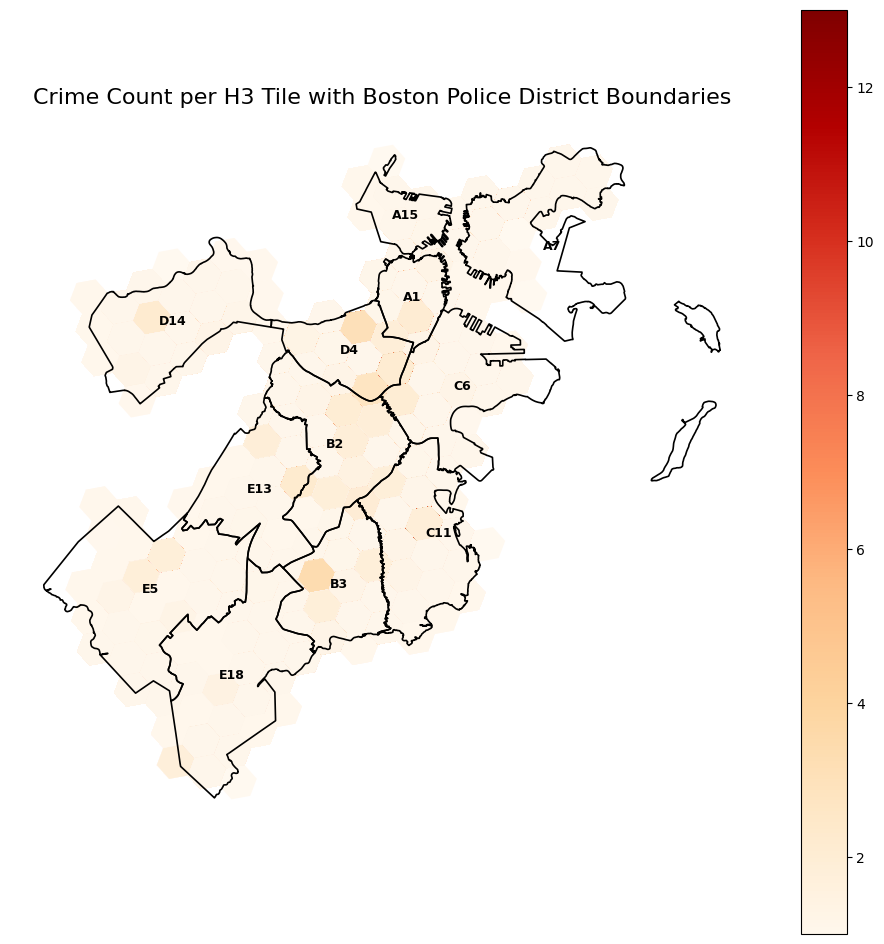

In [12]:
# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 12))

# lot H3 crime intensity as the base layer
# Make sure your gdf_tiles is in WGS84 (EPSG:4326)
gdf_tiles.to_crs("EPSG:4326").plot(
    column="crime_count",
    cmap="OrRd",
    legend=True,
    ax=ax,
    alpha=0.75
)

# Overlay Boston police districts as outlines only
districts.plot(
    ax=ax,
    facecolor="none",    # no fill
    edgecolor="black",   # outline color
    linewidth=1.2
)

# Add district labels at centroids
for district_id, row in districts.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(x, y, district_id, ha='center', va='center', fontsize=9, fontweight='bold')

ax.set_title(f"Crime Count per H3 Tile with Boston Police District Boundaries", fontsize=16)
ax.axis("off")

plt.show()

In [13]:
final_df

,h3_address,shift_date,shift,crime_count,target,Date,hour
0,882a3066a7fffff,2022-12-31 00:00:00+00:00,morning_noon,0.0,0,2022-12-31 06:00:00+00:00,6
1,882a3066a7fffff,2022-12-31 00:00:00+00:00,afternoon_night,0.0,0,2022-12-31 14:00:00+00:00,14
2,882a3066a7fffff,2022-12-31 00:00:00+00:00,overnight,0.0,0,2022-12-31 22:00:00+00:00,22
3,882a3066a7fffff,2023-01-01 00:00:00+00:00,morning_noon,0.0,0,2023-01-01 06:00:00+00:00,6
4,882a3066a7fffff,2023-01-01 00:00:00+00:00,afternoon_night,0.0,0,2023-01-01 14:00:00+00:00,14
...,...,...,...,...,...,...,...
635158,882a306669fffff,2025-12-30 00:00:00+00:00,afternoon_night,0.0,0,2025-12-30 14:00:00+00:00,14
635159,882a306669fffff,2025-12-30 00:00:00+00:00,overnight,0.0,0,2025-12-30 22:00:00+00:00,22
635160,882a306669fffff,2025-12-31 00:00:00+00:00,morning_noon,0.0,0,2025-12-31 06:00:00+00:00,6
635161,882a306669fffff,2025-12-31 00:00:00+00:00,afternoon_night,0.0,0,2025-12-31 14:00:00+00:00,14


In [14]:
# 1-Day Lag: What happened at this same shift yesterday?
# Group by tile AND shift so shift(1) compares same shift across days (true 1-day lag)
# e.g. morning_noon today <- morning_noon yesterday (not overnight 8h ago)
final_df['lag_1d'] = final_df.groupby(['h3_address', 'shift'])['crime_count'].shift(1)

# Rolling Averages: The 'Momentum' of the tile
# Group by tile AND shift so window=7 means 7 calendar days (not 7 shifts ~2.3 days)
# use shift(1) to avoid data leakage (don't include current day in the average)
final_df['rolling_7d_mean'] = (
    final_df.groupby(['h3_address', 'shift'])['crime_count']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

final_df['rolling_30d_mean'] = (
    final_df.groupby(['h3_address', 'shift'])['crime_count']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)



In [15]:
# =============================================================================
# FEATURE: Tile Crime Density Percentile (EWMA-based, no leakage)
# =============================================================================

# -----------------------------------------------------------------------------
# Step 1: Build daily tile-level totals (collapse across shifts)
# -----------------------------------------------------------------------------
daily_tile = (
    final_df
    .groupby(['h3_address', 'shift_date'])['crime_count']
    .sum()
    .reset_index()
    .sort_values(['h3_address', 'shift_date'])
    .reset_index(drop=True)
)

# -----------------------------------------------------------------------------
# Step 2: EWMA per tile (shift(1) prevents same-day leakage)
# halflife=30 days -> observation 30 days ago has 50% weight of today
# -----------------------------------------------------------------------------
daily_tile['tile_ewma_crime'] = (
    daily_tile
    .groupby('h3_address')['crime_count']
    .transform(lambda x: x.shift(1).ewm(halflife=30, min_periods=1).mean())
)

# -----------------------------------------------------------------------------
# Step 3: Percentile rank within each date (city-normalised, 0.0 to 1.0)
# fillna(0.5) on day 1: unknown history -> assume median, not safest
# -----------------------------------------------------------------------------
daily_tile['tile_crime_density_percentile'] = (
    daily_tile
    .groupby('shift_date')['tile_ewma_crime']
    .transform(lambda x: x.rank(pct=True))
    .fillna(0.5)
)

# -----------------------------------------------------------------------------
# Step 4: Merge back onto final_df (shift-level rows)
# -----------------------------------------------------------------------------
final_df = final_df.merge(
    daily_tile[['h3_address', 'shift_date', 'tile_crime_density_percentile']],
    on=['h3_address', 'shift_date'],
    how='left'
)

# -----------------------------------------------------------------------------
# Sanity checks
# -----------------------------------------------------------------------------
print("=== Tile Crime Density Percentile ===\n")

print("Distribution of tile_crime_density_percentile (should be ~uniform 0-1):")
print(final_df['tile_crime_density_percentile'].describe().round(4))

print("\nTop 10 tiles by current EWMA crime rate:")
print(
    daily_tile
    .sort_values('shift_date')
    .groupby('h3_address')
    .last()
    [['tile_ewma_crime', 'tile_crime_density_percentile']]
    .sort_values('tile_ewma_crime', ascending=False)
    .head(10)
    .round(4)
)

print("\nNull counts:")
print(final_df[['tile_crime_density_percentile']].isnull().sum())

=== Tile Crime Density Percentile ===

Distribution of tile_crime_density_percentile (should be ~uniform 0-1):
count    635163.0000
mean          0.5026
std           0.2879
min           0.0052
25%           0.2539
50%           0.5026
75%           0.7513
max           1.0000
Name: tile_crime_density_percentile, dtype: float64

Top 10 tiles by current EWMA crime rate:
                 tile_ewma_crime  tile_crime_density_percentile
h3_address                                                     
882a306631fffff           4.0964                         1.0000
882a3066b9fffff           3.2385                         0.9948
882a3066edfffff           2.5744                         0.9896
882a306615fffff           2.3934                         0.9845
882a30645bfffff           1.9176                         0.9793
882a3064c3fffff           1.6430                         0.9741
882a306617fffff           1.5166                         0.9689
882a30641bfffff           1.4917                   

In [16]:
# =============================================================================
# FEATURE: Tile Momentum
# =============================================================================

EPSILON = 1e-6

daily_tile['tile_ewma_fast'] = (
    daily_tile
    .groupby('h3_address')['crime_count']
    .transform(lambda x: x.shift(1).ewm(halflife=7, min_periods=1).mean())
)

daily_tile['tile_ewma_slow'] = (
    daily_tile
    .groupby('h3_address')['crime_count']
    .transform(lambda x: x.shift(1).ewm(halflife=30, min_periods=1).mean())
)

daily_tile['tile_momentum'] = (
    daily_tile['tile_ewma_fast'] / (daily_tile['tile_ewma_slow'] + EPSILON)
).fillna(1.0)  # no history yet -> assume at baseline, not accelerating

# Merge onto final_df
final_df = final_df.drop(
    columns=['tile_momentum'],
    errors='ignore'
)

final_df = final_df.merge(
    daily_tile[['h3_address', 'shift_date', 'tile_momentum']],
    on=['h3_address', 'shift_date'],
    how='left'
)

# Sanity check
print("tile_momentum distribution:")
print(final_df['tile_momentum'].describe().round(4))
print(f"\nCorrelation with target: {final_df['tile_momentum'].corr(final_df['target']):.4f}")

# Expected output:
#   mean ~= 1.0-1.2 (slight positive skew from hotspot tiles)
#   values below 0.5 = tiles that have cooled significantly
#   values above 2.0 = tiles in an active flare-up
print("\nValue distribution check:")
print(f"   Tiles at baseline (0.8-1.2) : {final_df['tile_momentum'].between(0.8, 1.2).mean():.1%}")
print(f"   Tiles cooling     (< 0.8)   : {(final_df['tile_momentum'] < 0.8).mean():.1%}")
print(f"   Tiles accelerating(> 1.2)   : {(final_df['tile_momentum'] > 1.2).mean():.1%}")

tile_momentum distribution:
count    635163.0000
mean          0.7428
std           0.6057
min           0.0000
25%           0.1155
50%           0.7953
75%           1.1104
max           4.1275
Name: tile_momentum, dtype: float64

Correlation with target: 0.1167

Value distribution check:
   Tiles at baseline (0.8-1.2) : 30.6%
   Tiles cooling     (< 0.8)   : 50.3%
   Tiles accelerating(> 1.2)   : 19.1%


In [17]:
# Cyclical time features: Encode day of week and month as sine/cosine pairs to capture cyclical patterns without introducing artificial discontinuities
# Extract basic components
final_df['day_of_week'] = final_df['Date'].dt.dayofweek
final_df['month'] = final_df['Date'].dt.month

# Sine/Cosine Transformation for Day of Week (0-6)
# Sunday (6) is adjacent to Monday (0)
final_df['day_sin'] = np.sin(2 * np.pi * final_df['day_of_week'] / 7)
final_df['day_cos'] = np.cos(2 * np.pi * final_df['day_of_week'] / 7)

# Sine/Cosine Transformation for Month (1-12)
# Subtract 1 from month to make it 0-11 for the transformation, so December (12) is adjacent to January (1)
final_df['month_sin'] = np.sin(2 * np.pi * (final_df['month']-1) / 12)
final_df['month_cos'] = np.cos(2 * np.pi * (final_df['month']-1) / 12)

# Shift identity — which 8-hour block is this?
# Two shift dummies — morning_noon is the baseline
final_df['is_afternoon_night'] = (final_df['shift'] == 'afternoon_night').astype(int)
final_df['is_overnight']       = (final_df['shift'] == 'overnight').astype(int)

# Weekend flag
final_df['is_weekend'] = final_df['day_of_week'].isin([5, 6]).astype(int)

# Simple Seasonal Darkness Proxy 
# Chicago: Winter months (Nov, Dec, Jan, Feb) have more dark hours in Shift 1 (Afternoon)
final_df['is_winter_evening'] = (
    (final_df['month'].isin([11, 12, 1, 2])) & 
    (final_df['shift'] == 'afternoon_night')
).astype(int)

In [18]:
# Spatial lag feature from neighboring H3 tiles 

def get_neighbor_stats(df):
    # 1) Build a lookup of the PREVIOUS shift's crime count for each (Date, h3_address).
    #    Sort by tile then time so shift(1) gives the immediately preceding shift.
    df_sorted = df.sort_values(['h3_address', 'Date'])
    prev_crime = (
        df_sorted
        .groupby('h3_address')['crime_count']
        .shift(1)          # previous shift's count (avoids concurrent leakage)
        .fillna(0)         # first shift of each tile has no prior -> treat as 0
    )

    # Map (current_Date, h3_address) -> previous shift's crime count
    prev_lookup = dict(zip(
        zip(df_sorted['Date'], df_sorted['h3_address']),
        prev_crime
    ))

    def calc_spatial_lag(row):
        # Find 1-ring neighbors (up to 6), excluding the tile itself
        neighbors = h3.grid_disk(row['h3_address'], k=1)
        neighbors = [n for n in neighbors if n != row['h3_address']]

        neighbor_counts = []
        for n in neighbors:
            # Look up PREVIOUS shift's crime count for neighbor n at the current Date.
            # This avoids leaking same-shift concurrent data from neighbors.
            count = prev_lookup.get((row['Date'], n), 0)
            neighbor_counts.append(count)

        return sum(neighbor_counts)

    # 2) Apply row-wise to create spatial lag feature
    # Note: this may take a few minutes on very large datasets
    df['neighbor_lag_1d'] = df.apply(calc_spatial_lag, axis=1)

    return df

final_df = get_neighbor_stats(final_df)

In [19]:
EPSILON = 1e-6  # prevents division by zero

# -----------------------------------------------------------------------------
# Step 1: Compute city-wide baseline per shift_date
# -----------------------------------------------------------------------------
city_daily_mean = (
    final_df
    .groupby('shift_date')['crime_count']
    .mean()
    .reset_index()
    .rename(columns={'crime_count': 'city_daily_mean'})
    .sort_values('shift_date')
)

# Expanding mean of the city baseline — avoids using future city-level data
# e.g. the normaliser on 2022-03-01 is the mean of all city daily means up to 2022-02-28
city_daily_mean['city_baseline'] = (
    city_daily_mean['city_daily_mean']
    .shift(1)
    .expanding()
    .mean()
)

# Fill day-1 NaN with the first available city mean (no prior history)
city_daily_mean['city_baseline'] = city_daily_mean['city_baseline'].fillna(
    city_daily_mean['city_daily_mean'].iloc[0]
)

# Merge city baseline onto final_df
final_df = final_df.merge(
    city_daily_mean[['shift_date', 'city_baseline']],
    on='shift_date',
    how='left'
)

# -----------------------------------------------------------------------------
# Step 2: Normalise rolling_30d_mean
# -----------------------------------------------------------------------------
final_df['rolling_30d_mean_norm'] = (
    final_df['rolling_30d_mean'] / (final_df['city_baseline'] + EPSILON)
)

# -----------------------------------------------------------------------------
# Step 3: Normalise rolling_7d_mean
# -----------------------------------------------------------------------------
final_df['rolling_7d_mean_norm'] = (
    final_df['rolling_7d_mean'] / (final_df['city_baseline'] + EPSILON)
)

# -----------------------------------------------------------------------------
# Step 4: Normalise neighbor_lag_1d
# -----------------------------------------------------------------------------
final_df['neighbor_lag_1d_norm'] = (
    final_df['neighbor_lag_1d'] / (final_df['city_baseline'] + EPSILON)
)

# -----------------------------------------------------------------------------
# Step 5: lag_1d — keep raw, add binary flag instead of normalising
# -----------------------------------------------------------------------------
final_df['is_crime_yesterday'] = (final_df['lag_1d'] > 0).astype(int)

# -----------------------------------------------------------------------------
# Sanity checks
# -----------------------------------------------------------------------------
print("=== City-Normalised Rolling Features ===\n")

print("city_baseline stats (should be a small positive number, stable over time):")
print(city_daily_mean['city_baseline'].describe().round(6))

print("\nrolling_30d_mean_norm (values >> 1.0 = persistent hotspot tiles):")
print(final_df['rolling_30d_mean_norm'].describe().round(4))

print("\nrolling_7d_mean_norm (values >> 1.0 = recently active tiles):")
print(final_df['rolling_7d_mean_norm'].describe().round(4))

print("\nneighbor_lag_1d_norm:")
print(final_df['neighbor_lag_1d_norm'].describe().round(4))

print("\nis_crime_yesterday value counts:")
print(final_df['is_crime_yesterday'].value_counts())

print("\nNull check:")
print(final_df[['rolling_30d_mean_norm', 'rolling_7d_mean_norm',
                'neighbor_lag_1d_norm', 'is_crime_yesterday']].isnull().sum())

# Drop any NaNs created by the shift (usually the first few rows of each tile)
final_df = final_df.dropna()

=== City-Normalised Rolling Features ===

city_baseline stats (should be a small positive number, stable over time):
count    1097.000000
mean        0.098109
std         0.005490
min         0.043178
25%         0.098238
50%         0.099972
75%         0.100628
max         0.101769
Name: city_baseline, dtype: float64

rolling_30d_mean_norm (values >> 1.0 = persistent hotspot tiles):
count    634584.0000
mean          1.0179
std           2.2438
min           0.0000
25%           0.0000
50%           0.3306
75%           0.9999
max          69.4784
Name: rolling_30d_mean_norm, dtype: float64

rolling_7d_mean_norm (values >> 1.0 = recently active tiles):
count    634584.0000
mean          1.0195
std           2.5050
min           0.0000
25%           0.0000
50%           0.0000
75%           1.4206
max          69.4784
Name: rolling_7d_mean_norm, dtype: float64

neighbor_lag_1d_norm:
count    635163.0000
mean          5.8598
std          11.0161
min           0.0000
25%           0.000

In [20]:
boston_features = final_df.copy()

# Los Angeles Data Preprocessing

In [21]:
df_crime_la.columns = ['incident_number','district','Date','time_occured','offense_description','Latitude','Longitude','crime_category']


In [22]:
# Ensure clean data within Los Angeles
LAT_MIN, LAT_MAX = 33.7, 34.4
LON_MIN, LON_MAX = -118.7, -117.9
df_crime_la = df_crime_la[
    (df_crime_la["Latitude"].between(LAT_MIN, LAT_MAX)) &
    (df_crime_la["Longitude"].between(LON_MIN, LON_MAX))
]
df_crime_la = df_crime_la[
    (df_crime_la["Latitude"] != 0) &
    (df_crime_la["Longitude"] != 0)
]

df_crime_la = df_crime_la.dropna(subset=["Latitude", "Longitude"])

In [23]:
df_crime_la = df_crime_la.loc[df_crime_la.crime_category != 'OTHERS']
df_crime_la["Date"] = pd.to_datetime(df_crime_la["Date"], errors="coerce")
# Ensure 'time_occured' is numeric
df_crime_la["time_occured"] = pd.to_numeric(df_crime_la["time_occured"], errors="coerce")
df_crime_la["hour"] = df_crime_la["time_occured"] // 100

# Update Date column to contain both date and time in the same data
df_crime_la["Date"] = pd.to_datetime(df_crime_la["Date"], errors="coerce")
df_crime_la["Date"] = df_crime_la["Date"] + pd.to_timedelta(df_crime_la["hour"], unit="h")


df_crime_la = df_crime_la.dropna()

C:\Users\rizky\AppData\Local\Temp\ipykernel_8288\1164110341.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_crime_la["Date"] = pd.to_datetime(df_crime_la["Date"], errors="coerce")


In [24]:
df_crime_la["Year"] = df_crime_la.Date.apply(lambda x: x.year)
df_crime_la = df_crime_la[(df_crime_la.Year >= 2022) & (df_crime_la.Year <= 2025)].reset_index(drop=True)

In [25]:
# Build H3 spatial grid and create shift-level target variable
# Shift bins: morning/noon (06:00-13:59), afternoon/night (14:00-21:59), overnight (22:00-05:59)

RESOLUTION = 8  # Higher number = smaller hexagons e.g. 8 is ~0.7km^2 area

# 1) Assign H3 cell id to each record
df_crime_la["h3_address"] = df_crime_la.apply(
    lambda row: h3.latlng_to_cell(row["Latitude"], row["Longitude"], RESOLUTION),
    axis=1
)

# 2) Clean copy: ensure datetime, drop missing coordinates/dates
df_shift = df_crime_la.copy()
df_shift["Date"] = pd.to_datetime(df_shift["Date"], errors="coerce")
df_shift = df_shift.dropna(subset=["Date", "h3_address"]).copy()

# 3) Assign each record to a shift and shift_date (anchored to shift start date)
hour = df_shift["Date"].dt.hour
df_shift["shift"] = np.select(
    [hour.between(6, 13), hour.between(14, 21)],
    ["morning_noon", "afternoon_night"],
    default="overnight"
)
df_shift["shift_date"] = df_shift["Date"].dt.floor("D")
df_shift.loc[hour < 6, "shift_date"] -= pd.Timedelta(days=1)

# 4) Build gdf_tiles for mapping (daily crime counts per tile)
def h3_to_polygon(hex_id):
    boundary = h3.cell_to_boundary(hex_id)  # (lat, lng)
    return Polygon([(lng, lat) for lat, lng in boundary])

tile_counts = (
    df_shift.groupby(["h3_address", df_shift["Date"].dt.date])
    .size().reset_index(name="crime_count")
)
tile_counts.columns = ["h3_address", "Date", "crime_count"]
gdf_tiles = gpd.GeoDataFrame(
    tile_counts,
    geometry=tile_counts["h3_address"].apply(h3_to_polygon),
    crs="EPSG:4326"
)

# 5) Aggregate crimes per tile per shift, then build master grid (every tile × date × shift)
tile_shift_counts = (
    df_shift.groupby(["h3_address", "shift_date", "shift"]).size().reset_index(name="crime_count")
)
shift_order = ["morning_noon", "afternoon_night", "overnight"]
index = pd.MultiIndex.from_product(
    [df_shift["h3_address"].unique(),
     pd.date_range(df_shift["shift_date"].min(), df_shift["shift_date"].max(), freq="D"),
     shift_order],
    names=["h3_address", "shift_date", "shift"]
)
master_grid = pd.DataFrame(index=index).reset_index()

# 6) Merge actual counts, fill zeros, create binary target
final_df = pd.merge(master_grid, tile_shift_counts, on=["h3_address", "shift_date", "shift"], how="left")
final_df["crime_count"] = final_df["crime_count"].fillna(0)
final_df["target"] = (final_df["crime_count"] > 0).astype(int)

# 7) Add Date and hour columns
# hour reflects the first (earliest) crime in that specific tile and shift;
# falls back to shift start hour for zero-crime rows
shift_start_hour = {"morning_noon": 6, "afternoon_night": 14, "overnight": 22}
final_df["Date"] = final_df["shift_date"] + pd.to_timedelta(final_df["shift"].map(shift_start_hour), unit="h")
hour_map = df_shift.groupby(["h3_address", "shift_date", "shift"])["Date"].apply(lambda x: int(x.min().hour)).to_dict()
final_df["hour"] = final_df.apply(
    lambda row: hour_map.get((row["h3_address"], row["shift_date"], row["shift"]), shift_start_hour[row["shift"]]),
    axis=1
)

print(f"H3 feature table created at resolution {RESOLUTION}")
print(f"Crime records used: {len(df_shift):,}")
print(f"Unique tiles: {df_shift['h3_address'].nunique():,}")
print(f"Shift-level rows in final_df: {len(final_df):,}")

H3 feature table created at resolution 8
Crime records used: 495,941
Unique tiles: 1,551
Shift-level rows in final_df: 5,099,688


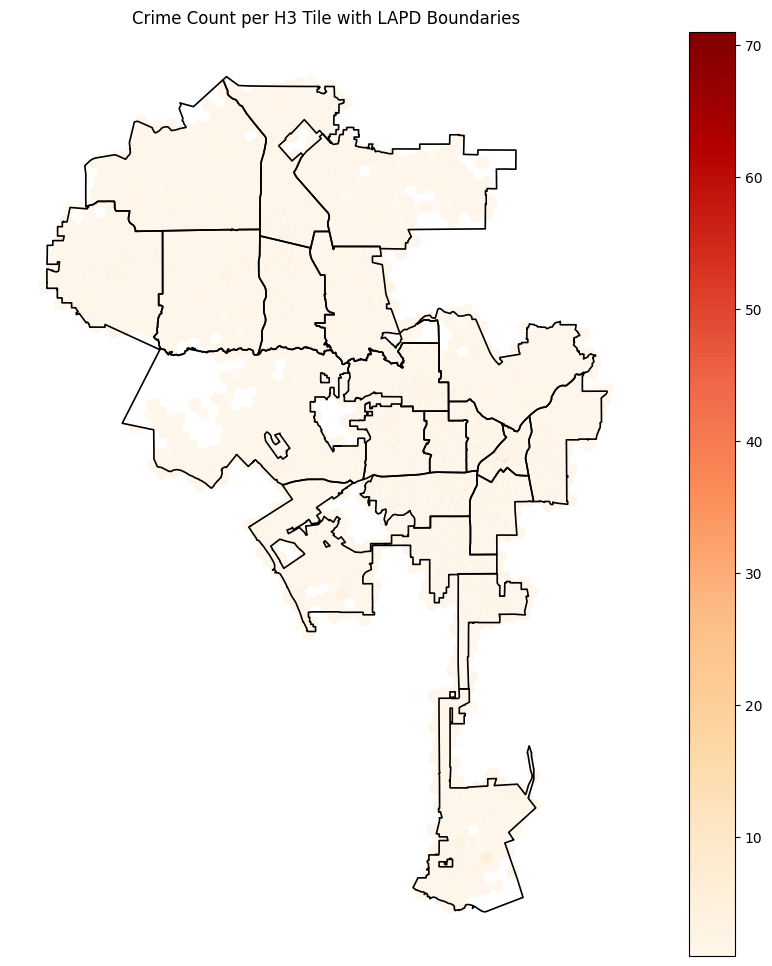

In [26]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 12))

# Plot tiles (with color)
gdf_tiles.to_crs("EPSG:4326").plot(
    column="crime_count",
    cmap="OrRd",
    legend=True,
    ax=ax,
    alpha=0.75
)

# Load LA districts
gdf = gpd.read_file("LAPoliceDistricts/LAPD_Map.geojson").to_crs("EPSG:4326")

# Overlay ONLY outlines
gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.2
)

ax.set_title("Crime Count per H3 Tile with LAPD Boundaries")
ax.axis("off")

plt.show()

In [27]:
# 1-Day Lag: What happened at this same shift yesterday?
# Group by tile AND shift so shift(1) compares same shift across days (true 1-day lag)
# e.g. morning_noon today <- morning_noon yesterday (not overnight 8h ago)
final_df['lag_1d'] = final_df.groupby(['h3_address', 'shift'])['crime_count'].shift(1)

# Rolling Averages: The 'Momentum' of the tile
# Group by tile AND shift so window=7 means 7 calendar days (not 7 shifts ~2.3 days)
# use shift(1) to avoid data leakage (don't include current day in the average)
final_df['rolling_7d_mean'] = (
    final_df.groupby(['h3_address', 'shift'])['crime_count']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

final_df['rolling_30d_mean'] = (
    final_df.groupby(['h3_address', 'shift'])['crime_count']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)


In [28]:
# =============================================================================
# FEATURE: Tile Crime Density Percentile (EWMA-based, no leakage)
# =============================================================================

# -----------------------------------------------------------------------------
# Step 1: Build daily tile-level totals (collapse across shifts)
# -----------------------------------------------------------------------------
daily_tile = (
    final_df
    .groupby(['h3_address', 'shift_date'])['crime_count']
    .sum()
    .reset_index()
    .sort_values(['h3_address', 'shift_date'])
    .reset_index(drop=True)
)

# -----------------------------------------------------------------------------
# Step 2: EWMA per tile (shift(1) prevents same-day leakage)
# halflife=30 days -> observation 30 days ago has 50% weight of today
# -----------------------------------------------------------------------------
daily_tile['tile_ewma_crime'] = (
    daily_tile
    .groupby('h3_address')['crime_count']
    .transform(lambda x: x.shift(1).ewm(halflife=30, min_periods=1).mean())
)

# -----------------------------------------------------------------------------
# Step 3: Percentile rank within each date (city-normalised, 0.0 to 1.0)
# fillna(0.5) on day 1: unknown history -> assume median, not safest
# -----------------------------------------------------------------------------
daily_tile['tile_crime_density_percentile'] = (
    daily_tile
    .groupby('shift_date')['tile_ewma_crime']
    .transform(lambda x: x.rank(pct=True))
    .fillna(0.5)
)

# -----------------------------------------------------------------------------
# Step 4: Merge back onto final_df (shift-level rows)
# -----------------------------------------------------------------------------
final_df = final_df.merge(
    daily_tile[['h3_address', 'shift_date', 'tile_crime_density_percentile']],
    on=['h3_address', 'shift_date'],
    how='left'
)

# -----------------------------------------------------------------------------
# Sanity checks
# -----------------------------------------------------------------------------
print("=== Tile Crime Density Percentile ===\n")

print("Distribution of tile_crime_density_percentile (should be ~uniform 0-1):")
print(final_df['tile_crime_density_percentile'].describe().round(4))

print("\nTop 10 tiles by current EWMA crime rate:")
print(
    daily_tile
    .sort_values('shift_date')
    .groupby('h3_address')
    .last()
    [['tile_ewma_crime', 'tile_crime_density_percentile']]
    .sort_values('tile_ewma_crime', ascending=False)
    .head(10)
    .round(4)
)

print("\nNull counts:")
print(final_df[['tile_crime_density_percentile']].isnull().sum())

=== Tile Crime Density Percentile ===

Distribution of tile_crime_density_percentile (should be ~uniform 0-1):
count    5.099688e+06
mean     5.003000e-01
std      2.882000e-01
min      6.000000e-04
25%      2.502000e-01
50%      5.000000e-01
75%      7.498000e-01
max      1.000000e+00
Name: tile_crime_density_percentile, dtype: float64

Top 10 tiles by current EWMA crime rate:
                 tile_ewma_crime  tile_crime_density_percentile
h3_address                                                     
8829a1d62dfffff           3.0791                         1.0000
8829a19b4bfffff           2.2778                         0.9994
8829a1d753fffff           1.8797                         0.9987
8829a1d705fffff           1.7311                         0.9981
8829a1d75bfffff           1.7149                         0.9974
8829a1d6d5fffff           1.4394                         0.9968
8829a1d751fffff           1.3939                         0.9961
8829a1d667fffff           1.2405           

In [29]:
# =============================================================================
# FEATURE: Tile Momentum
# =============================================================================

EPSILON = 1e-6

daily_tile['tile_ewma_fast'] = (
    daily_tile
    .groupby('h3_address')['crime_count']
    .transform(lambda x: x.shift(1).ewm(halflife=7, min_periods=1).mean())
)

daily_tile['tile_ewma_slow'] = (
    daily_tile
    .groupby('h3_address')['crime_count']
    .transform(lambda x: x.shift(1).ewm(halflife=30, min_periods=1).mean())
)

daily_tile['tile_momentum'] = (
    daily_tile['tile_ewma_fast'] / (daily_tile['tile_ewma_slow'] + EPSILON)
).fillna(1.0)  # no history yet -> assume at baseline, not accelerating

# Merge onto final_df
final_df = final_df.drop(
    columns=['tile_momentum'],
    errors='ignore'
)

final_df = final_df.merge(
    daily_tile[['h3_address', 'shift_date', 'tile_momentum']],
    on=['h3_address', 'shift_date'],
    how='left'
)

# Sanity check
print("tile_momentum distribution:")
print(final_df['tile_momentum'].describe().round(4))
print(f"\nCorrelation with target: {final_df['tile_momentum'].corr(final_df['target']):.4f}")

# Expected output:
#   mean ~= 1.0-1.2 (slight positive skew from hotspot tiles)
#   values below 0.5 = tiles that have cooled significantly
#   values above 2.0 = tiles in an active flare-up
print("\nValue distribution check:")
print(f"   Tiles at baseline (0.8-1.2) : {final_df['tile_momentum'].between(0.8, 1.2).mean():.1%}")
print(f"   Tiles cooling     (< 0.8)   : {(final_df['tile_momentum'] < 0.8).mean():.1%}")
print(f"   Tiles accelerating(> 1.2)   : {(final_df['tile_momentum'] > 1.2).mean():.1%}")

tile_momentum distribution:
count    5.099688e+06
mean     7.819000e-01
std      5.562000e-01
min      0.000000e+00
25%      3.304000e-01
50%      8.308000e-01
75%      1.106400e+00
max      4.127600e+00
Name: tile_momentum, dtype: float64

Correlation with target: 0.0938

Value distribution check:
   Tiles at baseline (0.8-1.2) : 34.0%
   Tiles cooling     (< 0.8)   : 47.5%
   Tiles accelerating(> 1.2)   : 18.5%


In [30]:
# Cyclical time features: Encode day of week and month as sine/cosine pairs to capture cyclical patterns without introducing artificial discontinuities
# Extract basic components
final_df['day_of_week'] = final_df['Date'].dt.dayofweek
final_df['month'] = final_df['Date'].dt.month

# Sine/Cosine Transformation for Day of Week (0-6)
# Sunday (6) is adjacent to Monday (0)
final_df['day_sin'] = np.sin(2 * np.pi * final_df['day_of_week'] / 7)
final_df['day_cos'] = np.cos(2 * np.pi * final_df['day_of_week'] / 7)

# Sine/Cosine Transformation for Month (1-12)
# Subtract 1 from month to make it 0-11 for the transformation, so December (12) is adjacent to January (1)
final_df['month_sin'] = np.sin(2 * np.pi * (final_df['month']-1) / 12)
final_df['month_cos'] = np.cos(2 * np.pi * (final_df['month']-1) / 12)

# Shift identity — which 8-hour block is this?
# Two shift dummies — morning_noon is the baseline
final_df['is_afternoon_night'] = (final_df['shift'] == 'afternoon_night').astype(int)
final_df['is_overnight']       = (final_df['shift'] == 'overnight').astype(int)

# Weekend flag
final_df['is_weekend'] = final_df['day_of_week'].isin([5, 6]).astype(int)

# Simple Seasonal Darkness Proxy 
# Chicago: Winter months (Nov, Dec, Jan, Feb) have more dark hours in Shift 1 (Afternoon)
final_df['is_winter_evening'] = (
    (final_df['month'].isin([11, 12, 1, 2])) & 
    (final_df['shift'] == 'afternoon_night')
).astype(int)

In [31]:
# Spatial lag feature from neighboring H3 tiles 

def get_neighbor_stats(df):
    # 1) Build a lookup of the PREVIOUS shift's crime count for each (Date, h3_address).
    #    Sort by tile then time so shift(1) gives the immediately preceding shift.
    df_sorted = df.sort_values(['h3_address', 'Date'])
    prev_crime = (
        df_sorted
        .groupby('h3_address')['crime_count']
        .shift(1)          # previous shift's count (avoids concurrent leakage)
        .fillna(0)         # first shift of each tile has no prior -> treat as 0
    )

    # Map (current_Date, h3_address) -> previous shift's crime count
    prev_lookup = dict(zip(
        zip(df_sorted['Date'], df_sorted['h3_address']),
        prev_crime
    ))

    def calc_spatial_lag(row):
        # Find 1-ring neighbors (up to 6), excluding the tile itself
        neighbors = h3.grid_disk(row['h3_address'], k=1)
        neighbors = [n for n in neighbors if n != row['h3_address']]

        neighbor_counts = []
        for n in neighbors:
            # Look up PREVIOUS shift's crime count for neighbor n at the current Date.
            # This avoids leaking same-shift concurrent data from neighbors.
            count = prev_lookup.get((row['Date'], n), 0)
            neighbor_counts.append(count)

        return sum(neighbor_counts)

    # 2) Apply row-wise to create spatial lag feature
    # Note: this may take a few minutes on very large datasets
    df['neighbor_lag_1d'] = df.apply(calc_spatial_lag, axis=1)

    return df

final_df = get_neighbor_stats(final_df)

In [32]:
EPSILON = 1e-6  # prevents division by zero

# -----------------------------------------------------------------------------
# Step 1: Compute city-wide baseline per shift_date
# -----------------------------------------------------------------------------
city_daily_mean = (
    final_df
    .groupby('shift_date')['crime_count']
    .mean()
    .reset_index()
    .rename(columns={'crime_count': 'city_daily_mean'})
    .sort_values('shift_date')
)

# Expanding mean of the city baseline — avoids using future city-level data
# e.g. the normaliser on 2022-03-01 is the mean of all city daily means up to 2022-02-28
city_daily_mean['city_baseline'] = (
    city_daily_mean['city_daily_mean']
    .shift(1)
    .expanding()
    .mean()
)

# Fill day-1 NaN with the first available city mean (no prior history)
city_daily_mean['city_baseline'] = city_daily_mean['city_baseline'].fillna(
    city_daily_mean['city_daily_mean'].iloc[0]
)

# Merge city baseline onto final_df
final_df = final_df.merge(
    city_daily_mean[['shift_date', 'city_baseline']],
    on='shift_date',
    how='left'
)

# -----------------------------------------------------------------------------
# Step 2: Normalise rolling_30d_mean
# -----------------------------------------------------------------------------
final_df['rolling_30d_mean_norm'] = (
    final_df['rolling_30d_mean'] / (final_df['city_baseline'] + EPSILON)
)

# -----------------------------------------------------------------------------
# Step 3: Normalise rolling_7d_mean
# -----------------------------------------------------------------------------
final_df['rolling_7d_mean_norm'] = (
    final_df['rolling_7d_mean'] / (final_df['city_baseline'] + EPSILON)
)

# -----------------------------------------------------------------------------
# Step 4: Normalise neighbor_lag_1d
# -----------------------------------------------------------------------------
final_df['neighbor_lag_1d_norm'] = (
    final_df['neighbor_lag_1d'] / (final_df['city_baseline'] + EPSILON)
)

# -----------------------------------------------------------------------------
# Step 5: lag_1d — keep raw, add binary flag instead of normalising
# -----------------------------------------------------------------------------
final_df['is_crime_yesterday'] = (final_df['lag_1d'] > 0).astype(int)

# -----------------------------------------------------------------------------
# Sanity checks
# -----------------------------------------------------------------------------
print("=== City-Normalised Rolling Features ===\n")

print("city_baseline stats (should be a small positive number, stable over time):")
print(city_daily_mean['city_baseline'].describe().round(6))

print("\nrolling_30d_mean_norm (values >> 1.0 = persistent hotspot tiles):")
print(final_df['rolling_30d_mean_norm'].describe().round(4))

print("\nrolling_7d_mean_norm (values >> 1.0 = recently active tiles):")
print(final_df['rolling_7d_mean_norm'].describe().round(4))

print("\nneighbor_lag_1d_norm:")
print(final_df['neighbor_lag_1d_norm'].describe().round(4))

print("\nis_crime_yesterday value counts:")
print(final_df['is_crime_yesterday'].value_counts())

print("\nNull check:")
print(final_df[['rolling_30d_mean_norm', 'rolling_7d_mean_norm',
                'neighbor_lag_1d_norm', 'is_crime_yesterday']].isnull().sum())

# Drop any NaNs created by the shift (usually the first few rows of each tile)
final_df = final_df.dropna()

=== City-Normalised Rolling Features ===

city_baseline stats (should be a small positive number, stable over time):
count    1096.000000
mean        0.111810
std         0.005738
min         0.049645
25%         0.109995
50%         0.114757
75%         0.115191
max         0.116376
Name: city_baseline, dtype: float64

rolling_30d_mean_norm (values >> 1.0 = persistent hotspot tiles):
count    5.095035e+06
mean     8.711000e-01
std      1.612900e+00
min      0.000000e+00
25%      0.000000e+00
50%      2.973000e-01
75%      1.152500e+00
max      1.007123e+02
Name: rolling_30d_mean_norm, dtype: float64

rolling_7d_mean_norm (values >> 1.0 = recently active tiles):
count    5.095035e+06
mean     8.637000e-01
std      1.897900e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.243500e+00
max      1.156526e+02
Name: rolling_7d_mean_norm, dtype: float64

neighbor_lag_1d_norm:
count    5.099688e+06
mean     5.039600e+00
std      1.027220e+01
min      0.000000e+00

In [33]:
la_features = final_df.copy()

# Save Boston and LA Engineered Feature Datasets

In [34]:
directory_path = "FeaturesDataset"

try:
    os.makedirs(directory_path, exist_ok=True)
    boston_features.to_parquet(directory_path + "/BostonCrimeFeatures.parquet")
    la_features.to_parquet(directory_path + "/LACrimeFeatures.parquet")
except OSError as e:
    print(f"An error occurred: {e}")
